In [1]:
import pandas as pd

df_evaluations_all=pd.read_json("./evaluations/evaluations_results_pipeline-QG.json")
print("DF shape;", df_evaluations_all.shape)
print("Corpus évalués:", df_evaluations_all["corpus"].unique())


df_evaluations=df_evaluations_all[df_evaluations_all["corpus"]=='Un-cerveau-comment-ca-marche'].reset_index().copy()
used_judges=[el.split("_")[-1] for el in df_evaluations.columns if "custom_evaluation_text" in el]
print("used_judges:\n", used_judges)

models_ratio_scores=[]
for judge in used_judges:
    label_metric=f"{judge}_ratio_score"
    score=round(df_evaluations[f"score_B (RAG)_{judge}"]/df_evaluations[f"score_A (réf.)_{judge}"], 2)    
    if score.any():
        df_evaluations[label_metric]=score
        models_ratio_scores.append(label_metric)

# df_evaluations["gemini-3-pro_ratio_score"]=round(df_evaluations["score_B (RAG)_gemini-3.1-pro-preview"]/df_evaluations["score_A (réf.)_gemini-3.1-pro-preview"], 2)

# df_evaluations["gpt-5.2_ratio_score"]=round(df_evaluations["score_B (RAG)_gpt-5.2"]/df_evaluations["score_A (réf.)_gpt-5.2"], 2)




# df_evaluations["deepseek-3.2_ratio_score"]=round(df_evaluations["score_B (RAG)_deepseek-v3.2"]/df_evaluations["score_A (réf.)_deepseek-v3.2"], 2)
# df_evaluations["kimi-k2.5_ratio_score"]=round(df_evaluations["score_B (RAG)_kimi-k2.5"]/df_evaluations["score_A (réf.)_kimi-k2.5"], 2)


display(df_evaluations.drop(columns=[
    "corpus", "question", "question_level", "date",
    "reponse_reference", "response",
    "custom_evaluation_text_claude-sonnet-4.6",  "custom_evaluation_text_gpt-5-mini", "custom_evaluation_text_gemini-3-flash-preview",
    "custom_evaluation_text_deepseek-v3.2", "custom_evaluation_text_kimi-k2.5",
    # "custom_evaluation_text_gemini-3.1-pro-preview"
    # "custom_evaluation_text_gpt-5.2",
    'score_A (réf.)_claude-sonnet-4.6', 'score_B (RAG)_claude-sonnet-4.6', 
    # 'score_A (réf.)_gemini-3.1-pro-preview', 'score_B (RAG)_gemini-3.1-pro-preview', 
     'score_A (réf.)_gemini-3-flash-preview', 'score_B (RAG)_gemini-3-flash-preview', 
     'score_A (réf.)_gpt-5.2', 'score_B (RAG)_gpt-5.2', 
    "score_A (réf.)_deepseek-v3.2", "score_B (RAG)_deepseek-v3.2" ,    
    "score_A (réf.)_kimi-k2.5", "score_B (RAG)_kimi-k2.5",    
    'score_A (réf.)_gpt-5-mini', 'score_B (RAG)_gpt-5-mini',    
]))

print("\n===Gap scores group by model et rag type:===\n")
for s in models_ratio_scores:    
    print(s)
    display(df_evaluations.groupby(["model", 'rag_type'])[s].mean().reset_index())



DF shape; (56, 30)
Corpus évalués: ['La-France-est-elle-reformable' 'L-IA-notre-deuxieme-conscience'
 'Un-cerveau-comment-ca-marche']
used_judges:
 ['claude-sonnet-4.6', 'gemini-3.1-pro-preview', 'gpt-5.2', 'gemini-3-flash-preview', 'gpt-5-mini', 'deepseek-v3.2', 'kimi-k2.5']


,index,question_label,rag_type,model,score_A (réf.)_gemini-3.1-pro-preview,score_B (RAG)_gemini-3.1-pro-preview,custom_evaluation_text_gemini-3.1-pro-preview,custom_evaluation_text_gpt-5.2,gemini-3.1-pro-preview_ratio_score,gpt-5.2_ratio_score,deepseek-v3.2_ratio_score,kimi-k2.5_ratio_score
0,44,question_cadre,graph,DeepSeek-V3.2:novita,9.0,7.0,"{'score_A': 9, 'score_B': 7, 'meilleure_repons...","{'score_A': 7, 'score_B': 8, 'meilleure_repons...",0.78,1.14,1.12,1.14
1,45,positions_interlocuteurs,graph,DeepSeek-V3.2:novita,8.0,6.0,"{'score_A': 8, 'score_B': 6, 'meilleure_repons...","{'score_A': 7, 'score_B': 6, 'meilleure_repons...",0.75,0.86,0.62,0.86
2,46,distinction entre faits et opinions,graph,DeepSeek-V3.2:novita,7.0,8.0,"{'score_A': 7, 'score_B': 8, 'meilleure_repons...","{'score_A': 8, 'score_B': 6, 'meilleure_repons...",1.14,0.75,NaN,0.78
3,47,verifiabilite_precision_retriever,graph,DeepSeek-V3.2:novita,9.0,5.0,"{'score_A': 9, 'score_B': 5, 'meilleure_repons...","{'score_A': 8, 'score_B': 6, 'meilleure_repons...",0.56,0.75,0.62,0.75
4,48,question_cadre,hybrid,DeepSeek-V3.2:novita,9.0,8.0,"{'score_A': 9, 'score_B': 8, 'meilleure_repons...","{'score_A': 7, 'score_B': 8, 'meilleure_repons...",0.89,1.14,0.88,1.12
5,49,positions_interlocuteurs,hybrid,DeepSeek-V3.2:novita,8.0,7.0,"{'score_A': 8, 'score_B': 7, 'meilleure_repons...","{'score_A': 7, 'score_B': 6, 'meilleure_repons...",0.88,0.86,1.14,0.67
6,50,verifiabilite_precision_retriever,hybrid,DeepSeek-V3.2:novita,9.0,6.0,"{'score_A': 9, 'score_B': 6, 'meilleure_repons...","{'score_A': 7, 'score_B': 9, 'meilleure_repons...",0.67,1.29,1.29,1.29
7,51,question_cadre,hybrid_hyde,DeepSeek-V3.2:novita,10.0,8.0,"{'score_A': 10, 'score_B': 8, 'meilleure_repon...","{'score_A': 7, 'score_B': 9, 'meilleure_repons...",0.80,1.29,1.14,1.12
8,52,positions_interlocuteurs,hybrid_hyde,DeepSeek-V3.2:novita,9.0,8.0,"{'score_A': 9, 'score_B': 8, 'meilleure_repons...","{'score_A': 6, 'score_B': 8, 'meilleure_repons...",0.89,1.33,1.14,1.29
9,53,verifiabilite_precision_retriever,hybrid_hyde,DeepSeek-V3.2:novita,9.0,8.0,"{'score_A': 9, 'score_B': 8, 'meilleure_repons...","{'score_A': 6, 'score_B': 9, 'meilleure_repons...",0.89,1.50,1.14,1.14



===Gap scores group by model et rag type:===

gemini-3.1-pro-preview_ratio_score


,model,rag_type,gemini-3.1-pro-preview_ratio_score
0,DeepSeek-V3.2:novita,graph,0.8075
1,DeepSeek-V3.2:novita,hybrid,0.8050
2,DeepSeek-V3.2:novita,hybrid_hyde,0.9250


gpt-5.2_ratio_score


,model,rag_type,gpt-5.2_ratio_score
0,DeepSeek-V3.2:novita,graph,0.875
1,DeepSeek-V3.2:novita,hybrid,1.145
2,DeepSeek-V3.2:novita,hybrid_hyde,1.315


deepseek-v3.2_ratio_score


,model,rag_type,deepseek-v3.2_ratio_score
0,DeepSeek-V3.2:novita,graph,0.786667
1,DeepSeek-V3.2:novita,hybrid,1.202500
2,DeepSeek-V3.2:novita,hybrid_hyde,1.187500


kimi-k2.5_ratio_score


,model,rag_type,kimi-k2.5_ratio_score
0,DeepSeek-V3.2:novita,graph,0.8825
1,DeepSeek-V3.2:novita,hybrid,1.0500
2,DeepSeek-V3.2:novita,hybrid_hyde,1.1725


In [ ]:
# inspecter une question
from IPython.display import Markdown
i=0
question=df_evaluations.loc[i, "question"]
resp=df_evaluations.loc[i, "response"]
ref=df_evaluations.loc[i, "reponse_reference"]
verdict=df_evaluations.loc[i, 'custom_evaluation_text_gemini-3.1-pro-preview']

print("\n=====\nQuestion:")
print(question)

print("\n=====\nRéponse:")
display(Markdown(resp))

print("\n----\nReference:", ref)

# display(Markdown(ref))

print(verdict)

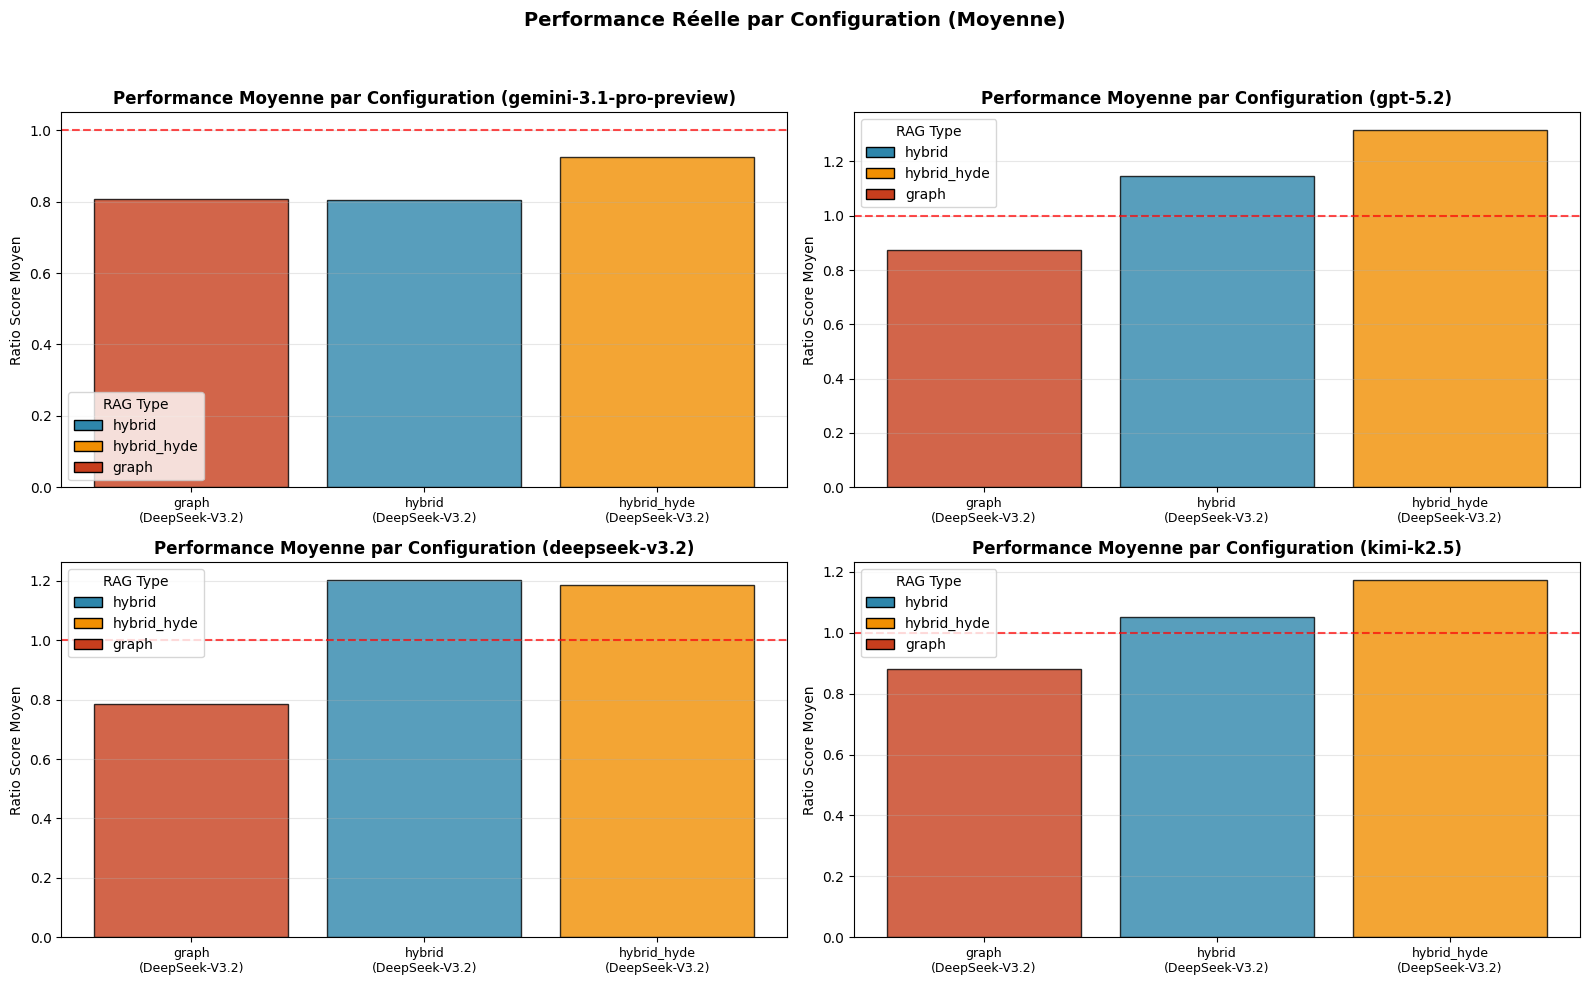

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df_viz = df_evaluations.copy()
df_viz['model_short'] = df_viz['model'].str.split(':').str[0]

# Calcul des moyennes
models_ratio_means=[
    {
        "label": m.split("_r")[0],
        "stats": df_viz.groupby(['model_short', 'rag_type'])[m].mean().reset_index()
    }
    for m in models_ratio_scores
]

# Correction 1: figsize plus grand pour 4 graphiques
# Correction 2: flatten() pour accéder aux axes en 1D
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

models = df_viz['model_short'].unique()
colors = {'hybrid': '#2E86AB', 'hybrid_hyde': '#F18F01', 'graph': '#C73E1D'}

axes_stats_models=[]
for axe, stats_model in zip(axes, models_ratio_means):
    print
    axes_stats_models.append((axe, stats_model["stats"], stats_model["label"]))
    
for ax, data, title in axes_stats_models:    
    x_pos = 0
    width = 0.25
    positions = []
    labels = []
    
    for model in models:
        subset = data[data['model_short'] == model]
        for _, row in subset.iterrows():
            positions.append(x_pos)
            labels.append(f"{row['rag_type']}\n({row['model_short']})")
            ax.bar(x_pos, row.iloc[2], width, 
                   color=colors[row['rag_type']], 
                   edgecolor='black', alpha=0.8)
            x_pos += width + 0.05
        
        x_pos += 0.1
    
    ax.axhline(1.0, color='red', linestyle='--', alpha=0.7)
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=0, ha='center', fontsize=9)
    ax.set_ylabel('Ratio Score Moyen', fontsize=10)
    ax.set_title(f'Performance Moyenne par Configuration ({title})', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors[r], edgecolor='black', label=r) 
                       for r in ['hybrid', 'hybrid_hyde', 'graph']]
    ax.legend(handles=legend_elements, title='RAG Type')

plt.suptitle('Performance Réelle par Configuration (Moyenne)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

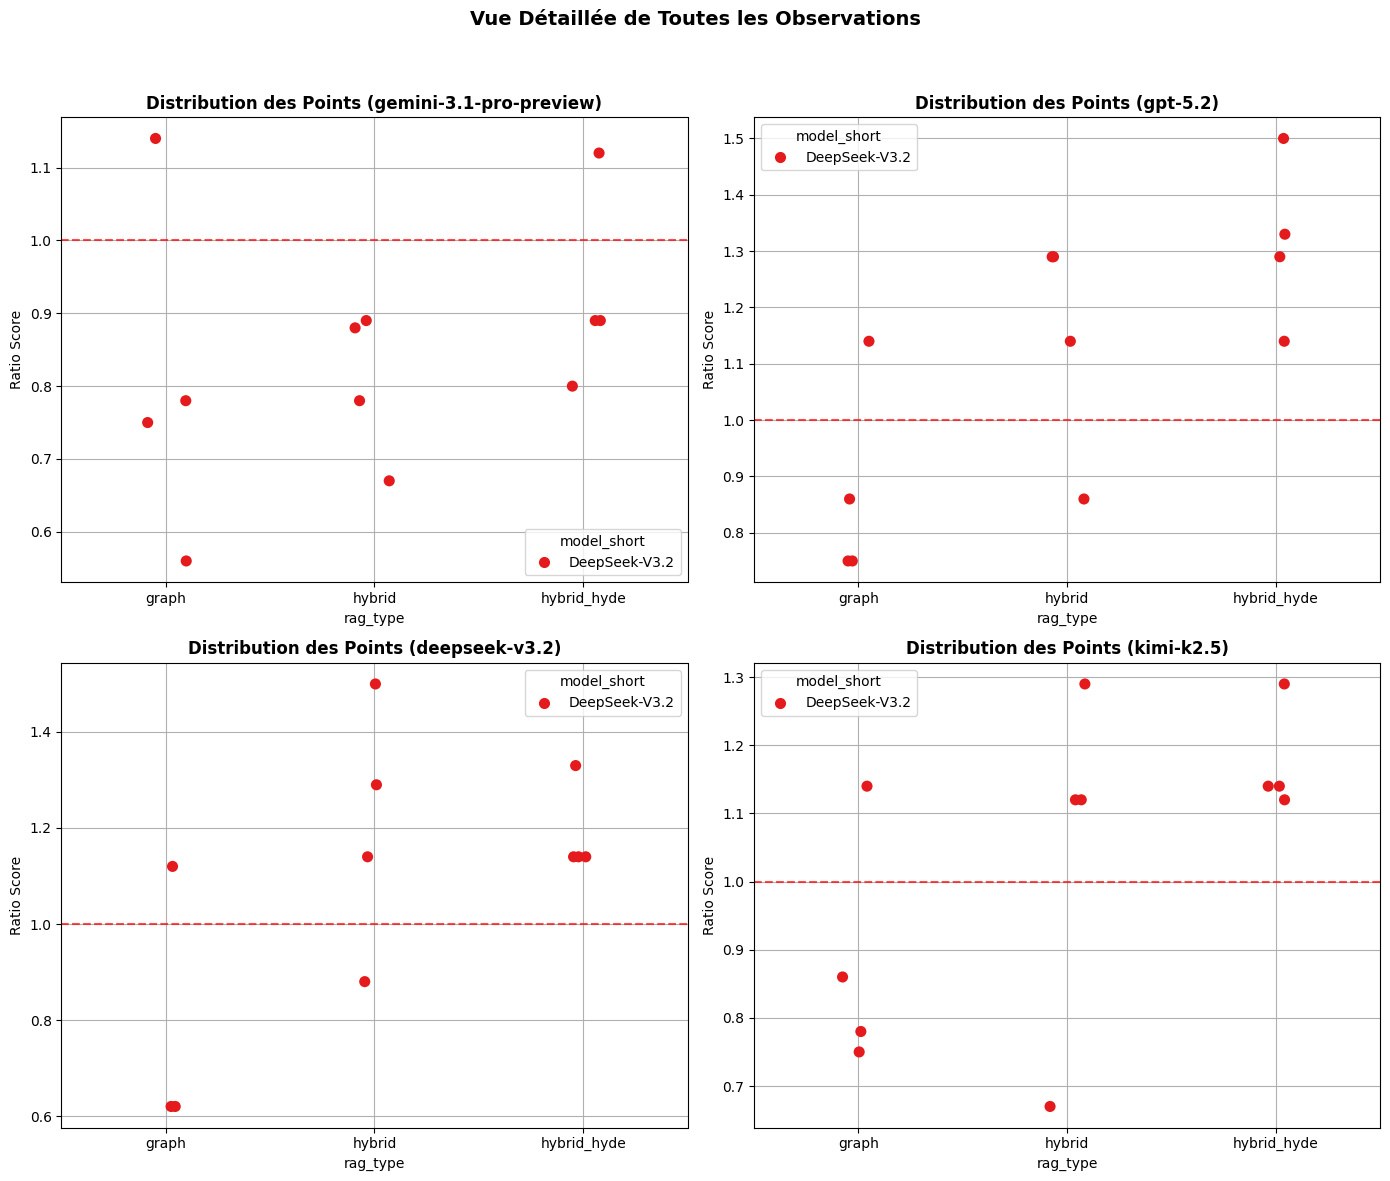

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()  # Correction : convertir en tableau 1D


for axe, model in zip(axes, models_ratio_scores):
    sns.stripplot(data=df_viz, x='rag_type', y=model, 
                hue='model_short', ax=axe, size=8, palette='Set1')
    axe.axhline(1.0, color='red', linestyle='--', alpha=0.7)
    axe.set_title(f'Distribution des Points ({model.split("_r")[0]})', fontweight='bold')
    axe.set_ylabel('Ratio Score')
    axe.grid()

plt.suptitle('Vue Détaillée de Toutes les Observations', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()